# 01 - Data Exploration: Delivery Performance Analysis

A first-pass exploratory analysis of a delivery operations dataset — covering data quality checks, delivery time distributions, delay reason analysis, and reusable functions for repeatable reporting.

**Dataset columns:** Order ID, Actual Delivery Date, Delay Reason, Driver ID, Driver Name, Hub Name, Is Delayed, Is On Time, Order Date, Order Status, Vehicle Name, Vehicle Type, Customer Satisfaction Score, Delivery Time Hours, Hub Processing Time Hours


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/DianaLara/Downloads/Orders.csv', encoding='UTF-16', sep='\t')
df.head()


,Order ID,Actual Delivery Date,Delay Reason,Driver ID,Driver Name,Hub Name,Is Delayed,Is On Time,Order Date,Order Status,Vehicle Name,Vehicle Type,Customer Satisfaction Score,Delivery Time Hours,Hub Processing Time Hours
0,1,25-10-2024,NaN,43,Karen Rodriguez,San Antonio Hub,False,True,25-10-2024,Delivered,FT-036,Truck,4,6.81,0.89
1,2,16-06-2024,NaN,29,Matthew Williams,Houston Hub,False,True,16-06-2024,Delivered,FT-016,Van,4,5.74,3.60
2,3,05-07-2024,NaN,25,Nancy Harris,Austin Hub,False,True,05-07-2024,Delivered,FT-040,Van,4,12.91,2.07
3,4,22-08-2023,NaN,20,David Davis,Fort Worth Hub,False,True,22-08-2023,Delivered,FT-039,Van,5,9.40,2.37
4,5,06-06-2024,Severe Weather,49,Joseph Williams,Dallas Main Hub,True,False,02-06-2024,Delivered,FT-018,Truck,3,103.48,1.80


## 1. Data Quality Checks

Before analyzing anything, it's worth checking for missing values and confirming data types are what we expect.

In [2]:
# Check for missing values in Delivery Time Hours
print(df['Delivery Time Hours'].isna().sum())

# Confirm data type is numeric
print(df['Delivery Time Hours'].dtype)


252
float64


**Finding:** missing `Delivery Time Hours` values traced back to `Cancelled` orders — orders that were never delivered have no delivery time by definition, not a data error.


In [3]:
print(df['Order Status'].value_counts())


Order Status
Delivered    27727
Cancelled      252
Name: count, dtype: int64


In [4]:
# Build a clean, delivered-only dataframe for analyses where cancelled orders shouldn't count
delivered_df = df[df['Order Status'] == 'Delivered'].copy()
print(f"Delivered orders: {len(delivered_df)} out of {len(df)} total")


Delivered orders: 27727 out of 27979 total


## 2. Delivery Time: Central Tendency

Average (mean), fastest (min), and slowest (max) delivery times, plus a mean-vs-median comparison to check for skew from outliers.

In [5]:
avg_delivery_time = df['Delivery Time Hours'].mean()
print(f"Average Delivery Time: {avg_delivery_time:.2f} hours")


Average Delivery Time: 35.78 hours


In [6]:
fastest_delivery = df['Delivery Time Hours'].min()
print(f"Fastest Delivery Time: {fastest_delivery:.2f} hours")

fastest_order = df.loc[df['Delivery Time Hours'].idxmin()]
print(fastest_order)


Fastest Delivery Time: 2.27 hours
Order ID                                 4271
Actual Delivery Date               08-09-2023
Delay Reason                              NaN
Driver ID                                   2
Driver Name                    Jennifer Lopez
Hub Name                          Houston Hub
Is Delayed                              False
Is On Time                               True
Order Date                         08-09-2023
Order Status                        Delivered
Vehicle Name                           FT-003
Vehicle Type                              Van
Customer Satisfaction Score                 5
Delivery Time Hours                      2.27
Hub Processing Time Hours                1.67
Name: 26132, dtype: object


In [7]:
slowest_delivery = df['Delivery Time Hours'].max()
print(f"Slowest Delivery Time: {slowest_delivery:.2f} hours")

slowest_order = df.loc[df['Delivery Time Hours'].idxmax()]
print(slowest_order)


Slowest Delivery Time: 143.14 hours
Order ID                                       26190
Actual Delivery Date                      06-04-2024
Delay Reason                   Package Sorting Error
Driver ID                                         11
Driver Name                             Linda Taylor
Hub Name                             San Antonio Hub
Is Delayed                                      True
Is On Time                                     False
Order Date                                01-04-2024
Order Status                               Delivered
Vehicle Name                                  FT-036
Vehicle Type                                   Truck
Customer Satisfaction Score                        4
Delivery Time Hours                           143.14
Hub Processing Time Hours                       1.74
Name: 3238, dtype: object


In [8]:
# 10 slowest deliveries - useful for spotting whether slow times are a pattern or one-off outliers
df.sort_values('Delivery Time Hours', ascending=False).head(10)


,Order ID,Actual Delivery Date,Delay Reason,Driver ID,Driver Name,Hub Name,Is Delayed,Is On Time,Order Date,Order Status,Vehicle Name,Vehicle Type,Customer Satisfaction Score,Delivery Time Hours,Hub Processing Time Hours
3238,26190,06-04-2024,Package Sorting Error,11,Linda Taylor,San Antonio Hub,True,False,01-04-2024,Delivered,FT-036,Truck,4,143.14,1.74
2195,13481,15-07-2024,Package Sorting Error,9,Patricia Jones,Houston Hub,True,False,10-07-2024,Delivered,FT-017,Truck,2,142.52,1.91
4448,26516,15-02-2024,Vehicle Breakdown,36,Donald Jackson,Austin Hub,True,False,10-02-2024,Delivered,FT-023,Van,3,141.85,1.29
4596,9441,10-09-2023,Incorrect Address,3,Linda Williams,Dallas Main Hub,True,False,05-09-2023,Delivered,FT-012,Van,3,141.80,0.93
6340,7164,12-09-2024,Package Sorting Error,4,Charles Thompson,Fort Worth Hub,True,False,07-09-2024,Delivered,FT-030,Van,4,141.47,3.80
3247,8245,01-12-2023,Road Construction,43,Karen Rodriguez,San Antonio Hub,True,False,26-11-2023,Delivered,FT-027,Truck,4,141.39,1.81
4376,22819,12-12-2024,Severe Weather,21,Patricia Martinez,Austin Hub,True,False,07-12-2024,Delivered,FT-007,Van,3,140.78,2.84
1380,19709,22-09-2023,Severe Weather,47,Mary Harris,Dallas Main Hub,True,False,17-09-2023,Delivered,FT-026,Box Truck,3,140.53,3.53
5383,8013,19-08-2023,Incorrect Address,14,Sarah Davis,Houston Hub,True,False,14-08-2023,Delivered,FT-019,Van,3,140.21,0.94
6219,7464,21-07-2024,Incorrect Address,38,Elizabeth Harris,El Paso Hub,True,False,16-07-2024,Delivered,FT-011,Van,4,139.84,1.03


In [9]:
mean_val = df['Delivery Time Hours'].mean()
median_val = df['Delivery Time Hours'].median()
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")


Mean: 35.78
Median: 33.06


**Finding:** the mean (35.78 hrs) is higher than the median (33.06 hrs), indicating right-skew — a handful of very slow deliveries are pulling the average upward, while most deliveries cluster closer to the median. This means the median is a better representation of a 'typical' delivery, while the mean is more sensitive to worst-case outliers.


<Axes: title={'center': 'Distribution of Delivery Times'}, ylabel='Frequency'>

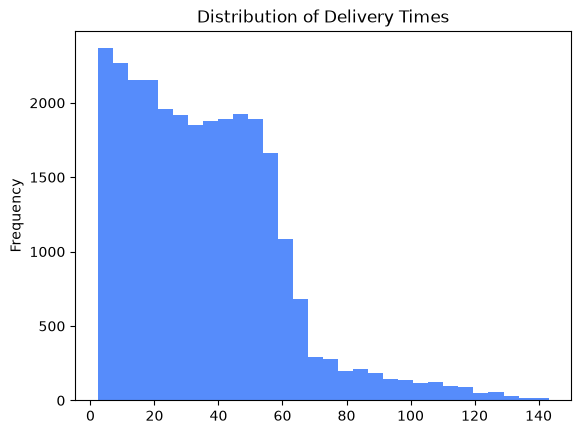

In [10]:
# Visualize the distribution (requires matplotlib: !pip install matplotlib)
df['Delivery Time Hours'].plot(kind='hist', bins=30, title='Distribution of Delivery Times')


## 3. Delay Reason Analysis

Understanding *why* deliveries are slow, not just how many are slow — including a specific check for damaged shipments.

In [15]:
def delay_reason_breakdown(df, hours=None, comparison='over'):
    """Show delay reason counts (and %) for deliveries matching a threshold.
    If hours=None, shows delay reasons for all deliveries.
    """
    if hours is not None:
        if comparison == 'over':
            subset = df[df['Delivery Time Hours'] > hours]
        else:
            subset = df[df['Delivery Time Hours'] < hours]
        print(f"\nDelay reasons for deliveries {comparison} {hours} hours (n={len(subset)}):")
    else:
        subset = df
        print(f"\nDelay reasons for all deliveries (n={len(subset)}):")

    counts = subset['Delay Reason'].value_counts()
    pct = subset['Delay Reason'].value_counts(normalize=True) * 100

    summary = pd.DataFrame({'count': counts, 'pct': pct.round(2)})
    return summary


In [16]:
delay_reason_breakdown(df, 120, 'over')



Delay reasons for deliveries over 120 hours (n=168):


,count,pct
Delay Reason,,
Driver Unavailable,24,14.29
Incorrect Address,21,12.50
Vehicle Breakdown,20,11.90
Hub Processing Delay,19,11.31
Multiple Delivery Stops,17,10.12
Road Construction,16,9.52
Severe Weather,16,9.52
Package Sorting Error,13,7.74
Customer Not Home,11,6.55


In [17]:
# Check exact wording used for shipment delays before filtering
print(df['Delay Reason'].unique())


<StringArray>
[                      nan,          'Severe Weather',
       'Customer Not Home',       'Incorrect Address',
       'Road Construction',   'Package Sorting Error',
       'Vehicle Breakdown',    'Hub Processing Delay',
 'Multiple Delivery Stops',      'Driver Unavailable',
      'Traffic Congestion']
Length: 11, dtype: str


In [26]:
# Partial text match - catches variations in spelling/capitalization
sorting_error = df[df['Delay Reason'].str.contains('Package Sorting Error', case=False, na=False)]
print(f"Sorting Error shipment delays: {len(sorting_error)} ({len(sorting_error)/len(df)*100:.2f}% of all deliveries)")


Sorting Error shipment delays: 603 (2.16% of all deliveries)


In [27]:
# Sorting Error shipments AND long delays - checks whether sorting errors correlates with the slowest deliveries
sorting_error_and_slow = df[
    (df['Delay Reason'].str.contains('Package Sorting Error', case=False, na=False)) &
    (df['Delivery Time Hours'] > 120)
]
print(f"Sorting Error AND over 120hrs: {len(damaged_and_slow)}")


Sorting Error AND over 120hrs: 0


## 4. Python Fundamentals Applied to This Dataset

A quick reference applying core Python built-ins (`len`, `sum`, `round`, `sorted`, `enumerate`, `zip`) directly to the delivery data, for reinforcement.


In [20]:
# len() - count items
print(len(df))
print(len(df['Hub Name'].unique()))


27979
6


In [21]:
# sum() - note: pandas' .sum() skips NaN automatically; Python's built-in sum() does not
# This returned NaN because the column contains missing values from cancelled orders:
# total_hours = sum(df['Delivery Time Hours'])  # returns nan if any NaNs are present

total_hours = df['Delivery Time Hours'].sum()  # pandas method - skips NaN automatically
print(f"Total delivery hours across all orders: {total_hours}")


Total delivery hours across all orders: 992085.47


In [22]:
# round() - round a number to N decimal places
avg_hours = df['Delivery Time Hours'].mean()
print(round(avg_hours, 2))


35.78


In [23]:
# sorted() - sort a plain Python list
hub_names = df['Hub Name'].unique().tolist()
print(sorted(hub_names))


['Austin Hub', 'Dallas Main Hub', 'El Paso Hub', 'Fort Worth Hub', 'Houston Hub', 'San Antonio Hub']


In [24]:
# enumerate() - loop through a list while tracking position
top_5_hubs = df.groupby('Hub Name')['Delivery Time Hours'].mean().sort_values().head(5)

for i, hub in enumerate(top_5_hubs.index, start=1):
    print(f"{i}. {hub} — {top_5_hubs[hub]:.2f} hrs avg")


1. El Paso Hub — 35.24 hrs avg
2. Austin Hub — 35.53 hrs avg
3. Dallas Main Hub — 35.78 hrs avg
4. Houston Hub — 35.79 hrs avg
5. San Antonio Hub — 35.79 hrs avg


In [25]:
# zip() - pair up two related lists/series element-by-element
hub_avg = df.groupby('Hub Name')['Delivery Time Hours'].mean()

for hub, avg in zip(hub_avg.index, hub_avg.values):
    print(f"{hub}: {avg:.2f} hrs")


Austin Hub: 35.53 hrs
Dallas Main Hub: 35.78 hrs
El Paso Hub: 35.24 hrs
Fort Worth Hub: 36.50 hrs
Houston Hub: 35.79 hrs
San Antonio Hub: 35.79 hrs


## Summary of Key Findings

- Dataset contains 27,979 orders; 252 (0.9%) are cancelled and have no delivery time — expected, not a data error.
- Average delivery time is 35.78 hours; median is 33.06 hours, indicating right-skew driven by a small number of slow outliers (120+ hours).
- Reusable `breakdown_by_group()` and `delay_reason_breakdown()` functions allow quick re-analysis across any threshold, direction, or grouping column (hub, driver, vehicle type).
- Next steps: explore `Customer Satisfaction Score` correlation with delivery time, and time-based trends using `Order Date`.
